## Imports

In [31]:
%load_ext autoreload
%autoreload 2
import jax

from eci.environment import Environment
from eci.metrics import batch_compute_metrics, compute_vote_shares
from eci.plots import plot_belief_trajectory, plot_preference
from eci.utils import get_voter_trajectory_data
from eci.voting_system.plurality import _vote_plurality
from eci.voting_system.quadratic import _vote_quadratic
from eci.voting_system.random_voting import _vote_random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameter Configuration 
The simulation constants are defined here.

In [19]:
NUM_VOTERS = 5  # Number of voters
NUM_CANDIDATES = 6  # Number of candidates
NUM_PREFERENCES = 3  # Number of preferences per voter
NUM_SIMULATIONS = 10  # Number of simulation steps (trajectories)

## Environment Initialization 
The environment is created using the parameters defined above.

In [20]:
# Initialize environment
env = Environment(
    num_voters=NUM_VOTERS,  # Number of voters
    num_candidates=NUM_CANDIDATES,  # Number of candidates
    num_preferences=NUM_PREFERENCES,  # Number of preferences
)
env.num_simulations = NUM_SIMULATIONS  # Number of simulations

## Running the Simulation

### Random Voting

In [ ]:
# Run perception
env._run_multi_agent_inference()

# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_rdm = env.run_n_simulation(_vote_random, key, NUM_SIMULATIONS)

# Update environment and agents
# env._update_agents()

# Compute metrics
metrics_rdm = batch_compute_metrics(sim_rdm)

# compute vote shares
distribution_rdm = compute_vote_shares(sim_rdm, num_candidates=7)

### Plurality Voting

In [ ]:
# Run perception
env._run_multi_agent_inference()

# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_plurality = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)

# Update environment and agents
# env._update_agents()

# Compute metrics
metrics_plurality = batch_compute_metrics(sim_plurality)

# compute vote shares
distribution_plurality = compute_vote_shares(sim_plurality, num_candidates=7)

### Quadratic Voting

In [ ]:
# Run perception
env._run_multi_agent_inference()

# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_qv = env.run_n_simulation(_vote_quadratic, key, NUM_SIMULATIONS)

# Update environment and agents
# env._update_agents()

# Compute metrics
metrics_qv = batch_compute_metrics(sim_qv)

# compute vote shares
distribution_qv = compute_vote_shares(sim_qv, num_candidates=7)

# Visualisation

# Metrics & Plots

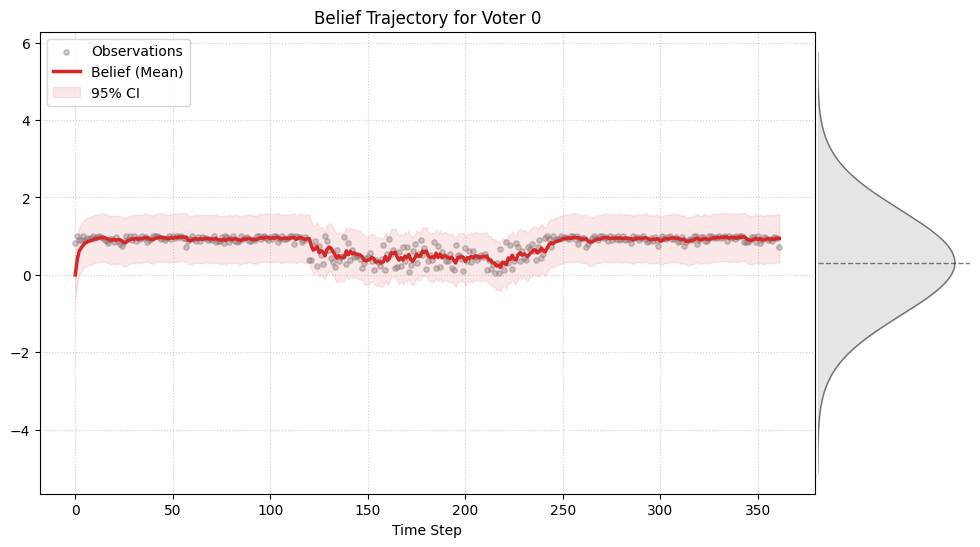

In [7]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_68605/3629702636.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_preference(env).show()


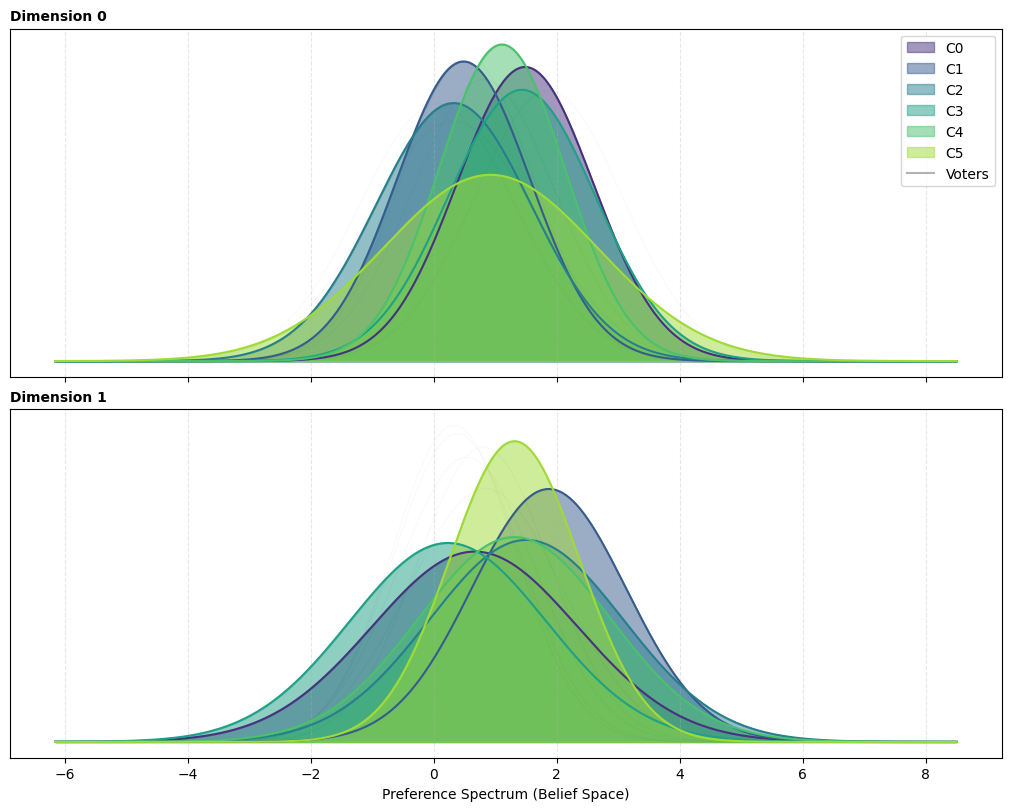

In [8]:
plot_preference(env).show()